#23_MarketBasketAnalysisusingAPIRIORI

### Importing the basic libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



### Load Dataset from Local Directory

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


### Importing the dataset

In [3]:
dataset = pd.read_csv('dataset.csv')

print("Shape:", dataset.shape)
print(dataset.head())

Shape: (7500, 20)
           shrimp    almonds     avocado    vegetables mix green grapes  \
0         burgers  meatballs        eggs               NaN          NaN   
1         chutney        NaN         NaN               NaN          NaN   
2          turkey    avocado         NaN               NaN          NaN   
3   mineral water       milk  energy bar  whole wheat rice    green tea   
4  low fat yogurt        NaN         NaN               NaN          NaN   

  whole weat flour yams cottage cheese energy drink tomato juice  \
0              NaN  NaN            NaN          NaN          NaN   
1              NaN  NaN            NaN          NaN          NaN   
2              NaN  NaN            NaN          NaN          NaN   
3              NaN  NaN            NaN          NaN          NaN   
4              NaN  NaN            NaN          NaN          NaN   

  low fat yogurt green tea honey salad mineral water salmon antioxydant juice  \
0            NaN       NaN   NaN   NaN   

## *Dynamic Transaction Creation*
# *Data Pre-Processing*

In [4]:
transactions = dataset.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

### Training APRIORI

In [5]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=7fcf28e512d565c3ab9f7572f8057f72c47ce85744af9cdd946426460cc4a19f
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [6]:
from apyori import apriori

rules = apriori(
    transactions=transactions,
    min_support=0.003,
    min_confidence=0.2,
    min_lift=3,
    min_length=2,
    max_length=2
)

# *Convert Results to Clean DataFrame*

In [7]:
results = list(rules)

clean_results = []

for result in results:
    for relation in result.ordered_statistics:
        clean_results.append([
            tuple(relation.items_base),
            tuple(relation.items_add),
            result.support,
            relation.confidence,
            relation.lift
        ])

df_results = pd.DataFrame(clean_results, columns=[
    'LHS', 'RHS', 'Support', 'Confidence', 'Lift'
])

print(df_results.head())

                       LHS             RHS   Support  Confidence      Lift
0           (light cream,)      (chicken,)  0.004533    0.290598  4.843305
1  (mushroom cream sauce,)     (escalope,)  0.005733    0.300699  3.790327
2                 (pasta,)     (escalope,)  0.005867    0.372881  4.700185
3         (fromage blanc,)        (honey,)  0.003333    0.245098  5.178128
4         (herb & pepper,)  (ground beef,)  0.016000    0.323450  3.291555


### Results in Dataframe

In [8]:
lhs         = [tuple(result[2][0][0])[0] for result in results]
rhs         = [tuple(result[2][0][1])[0] for result in results]
supports    = [result[1] for result in results]
confidences = [result[2][0][2] for result in results]
lifts       = [result[2][0][3] for result in results]
resultsinDataFrame = pd.DataFrame(zip(lhs, rhs, supports, confidences, lifts), columns = ['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])
resultsinDataFrame

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,light cream,chicken,0.004533,0.290598,4.843305
1,mushroom cream sauce,escalope,0.005733,0.300699,3.790327
2,pasta,escalope,0.005867,0.372881,4.700185
3,fromage blanc,honey,0.003333,0.245098,5.178128
4,herb & pepper,ground beef,0.016000,0.323450,3.291555
5,tomato sauce,ground beef,0.005333,0.377358,3.840147
6,light cream,olive oil,0.003200,0.205128,3.120612
7,whole wheat pasta,olive oil,0.008000,0.271493,4.130221
8,pasta,shrimp,0.005067,0.322034,4.514494


# *Sort Best Rules*

In [9]:
df_results = df_results.sort_values(by='Lift', ascending=False)
print(df_results.head(10))

                       LHS             RHS   Support  Confidence      Lift
3         (fromage blanc,)        (honey,)  0.003333    0.245098  5.178128
0           (light cream,)      (chicken,)  0.004533    0.290598  4.843305
2                 (pasta,)     (escalope,)  0.005867    0.372881  4.700185
8                 (pasta,)       (shrimp,)  0.005067    0.322034  4.514494
7     (whole wheat pasta,)    (olive oil,)  0.008000    0.271493  4.130221
5          (tomato sauce,)  (ground beef,)  0.005333    0.377358  3.840147
1  (mushroom cream sauce,)     (escalope,)  0.005733    0.300699  3.790327
4         (herb & pepper,)  (ground beef,)  0.016000    0.323450  3.291555
6           (light cream,)    (olive oil,)  0.003200    0.205128  3.120612


# *Filter Strong Rules*

In [10]:
strong_rules = df_results[
    (df_results['Confidence'] > 0.5) &
    (df_results['Lift'] > 3)
]

print(strong_rules)

Empty DataFrame
Columns: [LHS, RHS, Support, Confidence, Lift]
Index: []


# *Visualization*

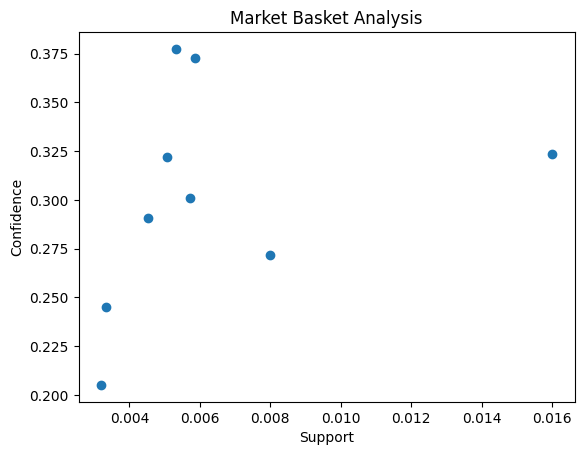

In [11]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

plt.scatter(df_results['Support'], df_results['Confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Market Basket Analysis')
plt.show()

# Applying Apriori using MLXTEND (Industry Approach)

# *Convert to One-Hot Encoding*

In [12]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

df.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# *apply apriori*

In [13]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(df, min_support=0.003, use_colnames=True)

rules = association_rules(frequent_items, metric="lift", min_threshold=3)

print(rules.head())

        antecedents             consequents  antecedent support  \
0  (cottage cheese)              (brownies)            0.031733   
1        (brownies)        (cottage cheese)            0.033733   
2     (light cream)               (chicken)            0.015600   
3         (chicken)           (light cream)            0.060000   
4        (escalope)  (mushroom cream sauce)            0.079333   

   consequent support   support  confidence      lift  representativity  \
0            0.033733  0.003467    0.109244  3.238450               1.0   
1            0.031733  0.003467    0.102767  3.238450               1.0   
2            0.060000  0.004533    0.290598  4.843305               1.0   
3            0.015600  0.004533    0.075556  4.843305               1.0   
4            0.019067  0.005733    0.072269  3.790327               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0  0.002396    1.084771       0.713864  0.055914   0.078147    0.106005 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# *Generate Rules*

In [14]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="lift", min_threshold=3)

rules.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(cottage cheese),(brownies),0.031733,0.033733,0.003467,0.109244,3.238450,1.0,0.002396,1.084771,0.713864,0.055914,0.078147,0.106005
1,(brownies),(cottage cheese),0.033733,0.031733,0.003467,0.102767,3.238450,1.0,0.002396,1.079169,0.715341,0.055914,0.073361,0.106005
2,(light cream),(chicken),0.015600,0.060000,0.004533,0.290598,4.843305,1.0,0.003597,1.325060,0.806105,0.063790,0.245317,0.183077
3,(chicken),(light cream),0.060000,0.015600,0.004533,0.075556,4.843305,1.0,0.003597,1.064856,0.844180,0.063790,0.060906,0.183077
4,(escalope),(mushroom cream sauce),0.079333,0.019067,0.005733,0.072269,3.790327,1.0,0.004221,1.057347,0.799606,0.061871,0.054236,0.186484


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# *Sort Rules*

In [15]:
rules = rules.sort_values(by='lift', ascending=False)
rules.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
345,"(soup, frozen vegetables)","(mineral water, milk)",0.008000,0.048000,0.003067,0.383333,7.986111,1.0,0.002683,1.543784,0.881837,0.057935,0.352241,0.223611
340,"(mineral water, milk)","(soup, frozen vegetables)",0.048000,0.008000,0.003067,0.063889,7.986111,1.0,0.002683,1.059703,0.918889,0.057935,0.056340,0.223611
176,(olive oil),"(mineral water, whole wheat pasta)",0.065733,0.009600,0.003867,0.058824,6.127451,1.0,0.003236,1.052300,0.895676,0.054104,0.049701,0.230801
329,"(olive oil, frozen vegetables)","(mineral water, milk)",0.011333,0.048000,0.003333,0.294118,6.127451,1.0,0.002789,1.348667,0.846392,0.059524,0.258527,0.181781
330,"(mineral water, milk)","(olive oil, frozen vegetables)",0.048000,0.011333,0.003333,0.069444,6.127451,1.0,0.002789,1.062448,0.878992,0.059524,0.058777,0.181781
175,"(mineral water, whole wheat pasta)",(olive oil),0.009600,0.065733,0.003867,0.402778,6.127451,1.0,0.003236,1.564353,0.844911,0.054104,0.360758,0.230801
240,"(shrimp, mineral water)","(chocolate, frozen vegetables)",0.023467,0.022933,0.003200,0.136364,5.946089,1.0,0.002662,1.131340,0.851811,0.074074,0.116093,0.137949
245,"(chocolate, frozen vegetables)","(shrimp, mineral water)",0.022933,0.023467,0.003200,0.139535,5.946089,1.0,0.002662,1.134890,0.851346,0.074074,0.118857,0.137949
343,"(milk, soup)","(mineral water, frozen vegetables)",0.015200,0.035733,0.003067,0.201754,5.646112,1.0,0.002524,1.207982,0.835588,0.064067,0.172173,0.143788
342,"(mineral water, frozen vegetables)","(milk, soup)",0.035733,0.015200,0.003067,0.085821,5.646112,1.0,0.002524,1.077251,0.853381,0.064067,0.071711,0.143788


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
input_item = 'milk'

filtered_rules = rules[rules['antecedents'].apply(lambda x: input_item in x)]

filtered_rules[['antecedents', 'consequents', 'confidence', 'lift']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,confidence,lift
340,"(mineral water, milk)","(soup, frozen vegetables)",0.063889,7.986111
330,"(mineral water, milk)","(olive oil, frozen vegetables)",0.069444,6.127451
343,"(milk, soup)","(mineral water, frozen vegetables)",0.201754,5.646112
344,"(milk, frozen vegetables)","(mineral water, soup)",0.129944,5.633389
337,"(mineral water, milk, frozen vegetables)",(soup),0.277108,5.483676
...,...,...,...,...
381,"(spaghetti, milk)","(mineral water, ground beef)",0.124060,3.030785
408,"(mineral water, milk)","(spaghetti, olive oil)",0.069444,3.028101
350,"(spaghetti, mineral water, milk)",(frozen vegetables),0.288136,3.022401
412,"(mineral water, milk)","(shrimp, spaghetti)",0.063889,3.013627


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
